In [2]:
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ultranest
from ultranest.plot import PredictionBand, cornerplot
import pickle
from pathlib import Path
from ultranest.stepsampler import SliceSampler, generate_mixture_random_direction


In [3]:
data = np.loadtxt("Land_and_Ocean_complete_annual.txt", comments="%")
columns = [
    "year",
    "annual_anomaly_above", "annual_unc_above",
    "five_year_anomaly_above", "five_year_unc_above",
    "annual_anomaly_below", "annual_unc_below",
    "five_year_anomaly_below", "five_year_unc_below",
]

df = pd.DataFrame(data, columns=columns)

dtype_map = {
    "year": "int",
    "annual_anomaly_above": "float",
    "annual_unc_above": "float",
    "five_year_anomaly_above": "float",
    "five_year_unc_above": "float",
    "annual_anomaly_below": "float",
    "annual_unc_below": "float",
    "five_year_anomaly_below": "float",
    "five_year_unc_below": "float",
}
df = df.astype(dtype_map)
# 95% uncertainty in data
yerr_above = df["annual_unc_above"] / 1.96
yerr_below = df["annual_unc_below"] / 1.96

date = df["year"].values
# normalize years to the range [0, 1] for bettter numerical stability
date_normalized = (date - date.min()) / (date.max() - date.min())
temp_anomaly = df["annual_anomaly_above"].values
sigma2 = yerr_above ** 2

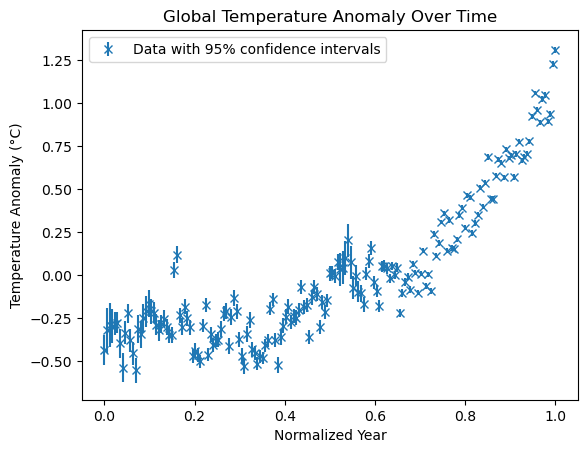

In [3]:
#plot the data normalized
plt.errorbar(date_normalized, temp_anomaly, yerr=yerr_above, fmt="x", label="Data with 95% confidence intervals")
plt.xlabel("Normalized Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Global Temperature Anomaly Over Time")
plt.legend()
plt.show()

## Polynomial trend

$$ T(t) = q + a_1 \cdot t + a_2 \cdot t^2 + ... $$
with $t$ normalized.

In [9]:
# convert prior range [1, 70] to normalized years
P_min, P_max = 1, 70
P_normalized_min = (P_min) / (date.max() - date.min())
P_normalized_max = (P_max) / (date.max() - date.min())
print(f"Normalized period range: [{P_normalized_min:.3f}, {P_normalized_max:.3f}]")

Normalized period range: [0.006, 0.402]


In [10]:
def poly_model(t, q, a_1, a_2, a_3):
    return q + a_1 * t + a_2 * t**2 + a_3 * t**3

def poly_prior(cube):
    theta = cube.copy()

    # q in [-2, 2]
    theta[0] = cube[0] * 4 - 2
    # a_1 in [-5.0, 5.0]
    theta[1] = cube[1] * 10.0 - 5.0
    # a_2 in [-5.0, 5.0]
    theta[2] = cube[2] * 10.0 - 5.0
    # a_3 in [-5.0, 5.0]
    theta[3] = cube[3] * 10.0 - 5.0

    return theta


def log_poly_likelihood(theta):
    q, a_1, a_2, a_3 = theta
    model = poly_model(date_normalized, q, a_1, a_2, a_3)

    residuals = temp_anomaly - model
    log_likelihood_value = -0.5 * np.sum(
        np.log(2 * np.pi * sigma2) + (residuals ** 2) / sigma2
    )

    return log_likelihood_value


parameters_poly = ["q", "a_1", "a_2", "a_3"]

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-1e+03  291.94 [-1292.0716..-1292.0715]*| it/evals=10320/20833 eff=50.5065% N=400  0  00 
[ultranest] Likelihood function evaluations: 20833
[ultranest]   logZ = -1313 +- 0.1514
[ultranest] Effective samples strategy satisfied (ESS = 2104.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.15, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.15 tail:0.01 total:0.15 required:<0.50
[ultranest] done iterating.

logZ = -1313.223 +- 0.407
  single instance: logZ = -1313.223 +- 0.220
  bootstrapped   : logZ = -1313.204 +- 0.407
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    q                   : -0.414│ ▁▁▁▁▁▁▁▁▁▂▃▄▅▅▆▇▆▇▆▆▅▄▃▂▂▁▁▁▁▁▁▁ ▁  ▁ │-0.245    -0.338 +- 0.019
    a_1                 : -0.25 │ ▁  ▁▁▁▁▁▁▁▂▂▂▄▄▅▆▇▇▇▆▇▆▄▃▃▂▂▁▁▁▁▁▁▁▁▁ │0.84      0.31 +- 0.12
    a_2       

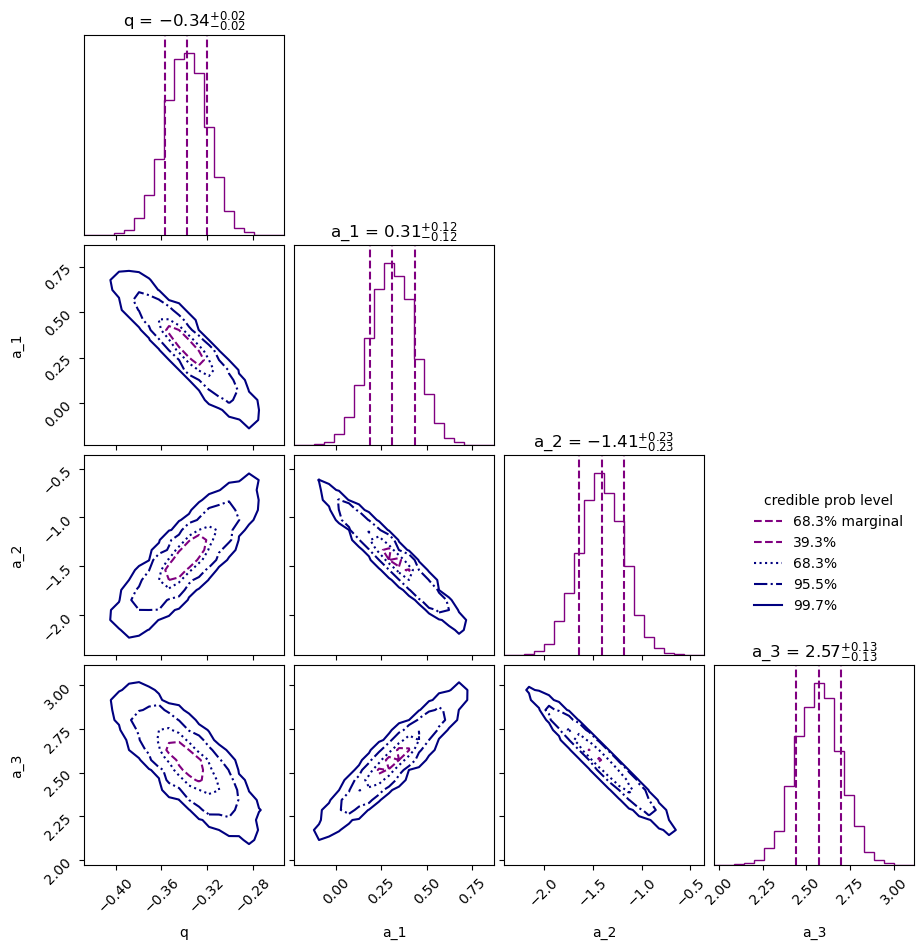

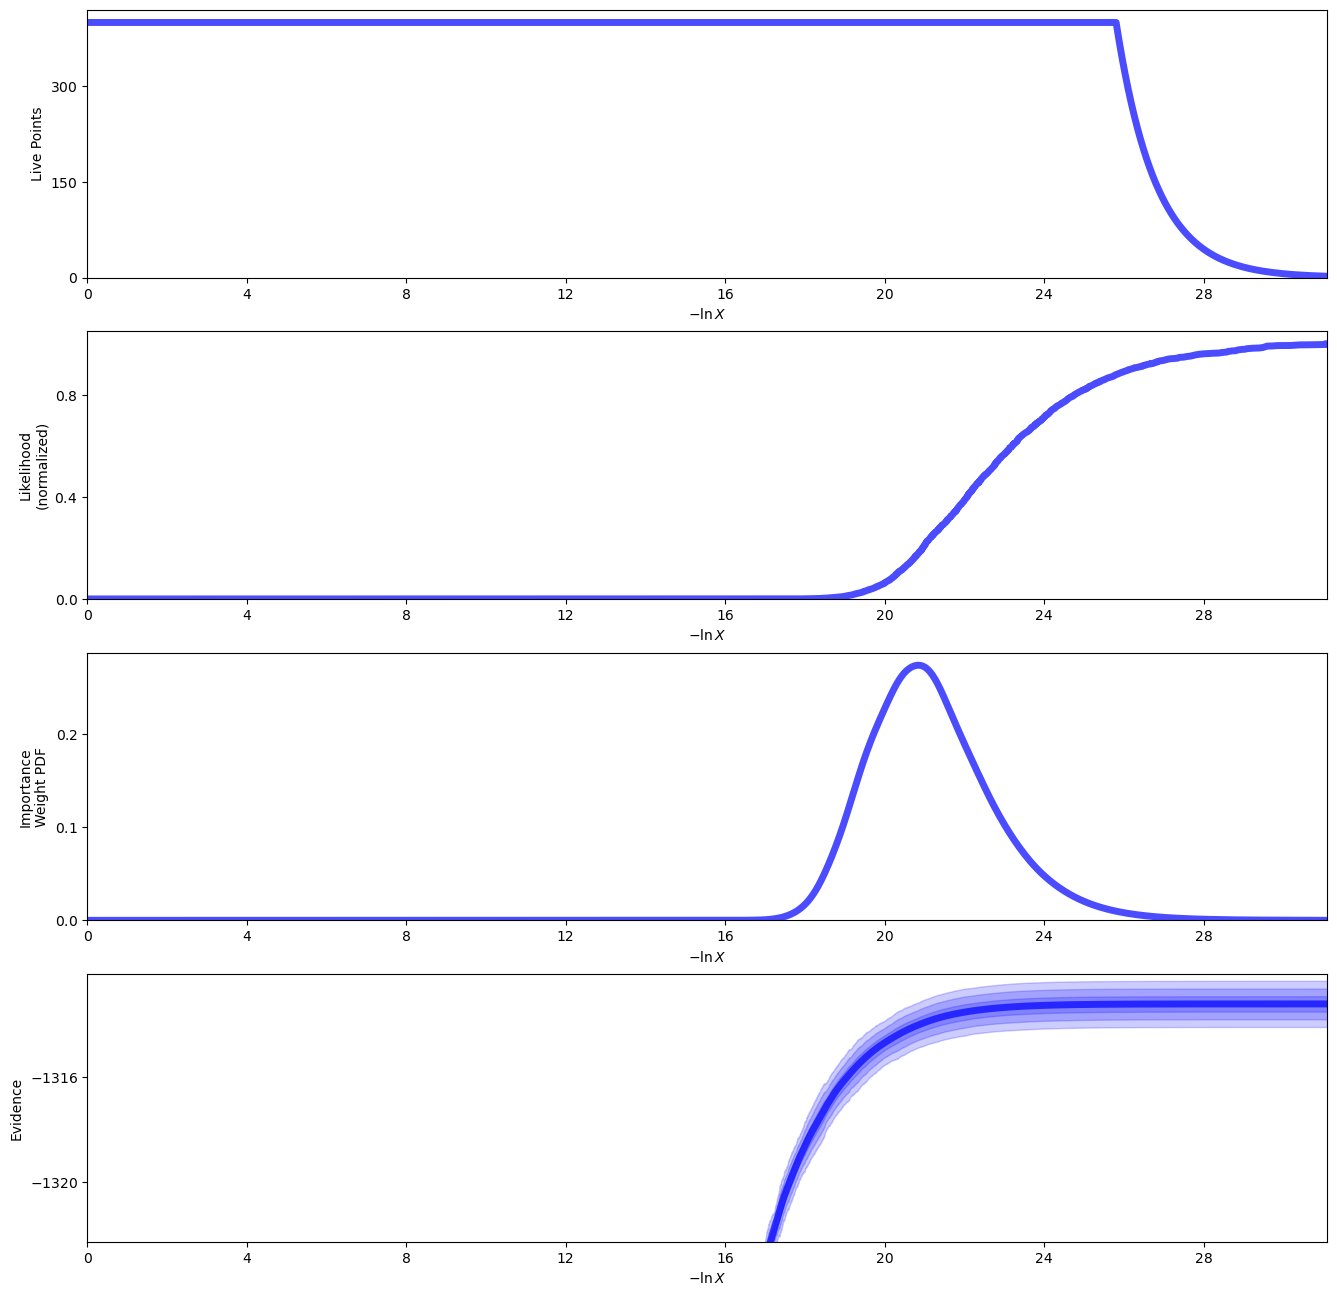

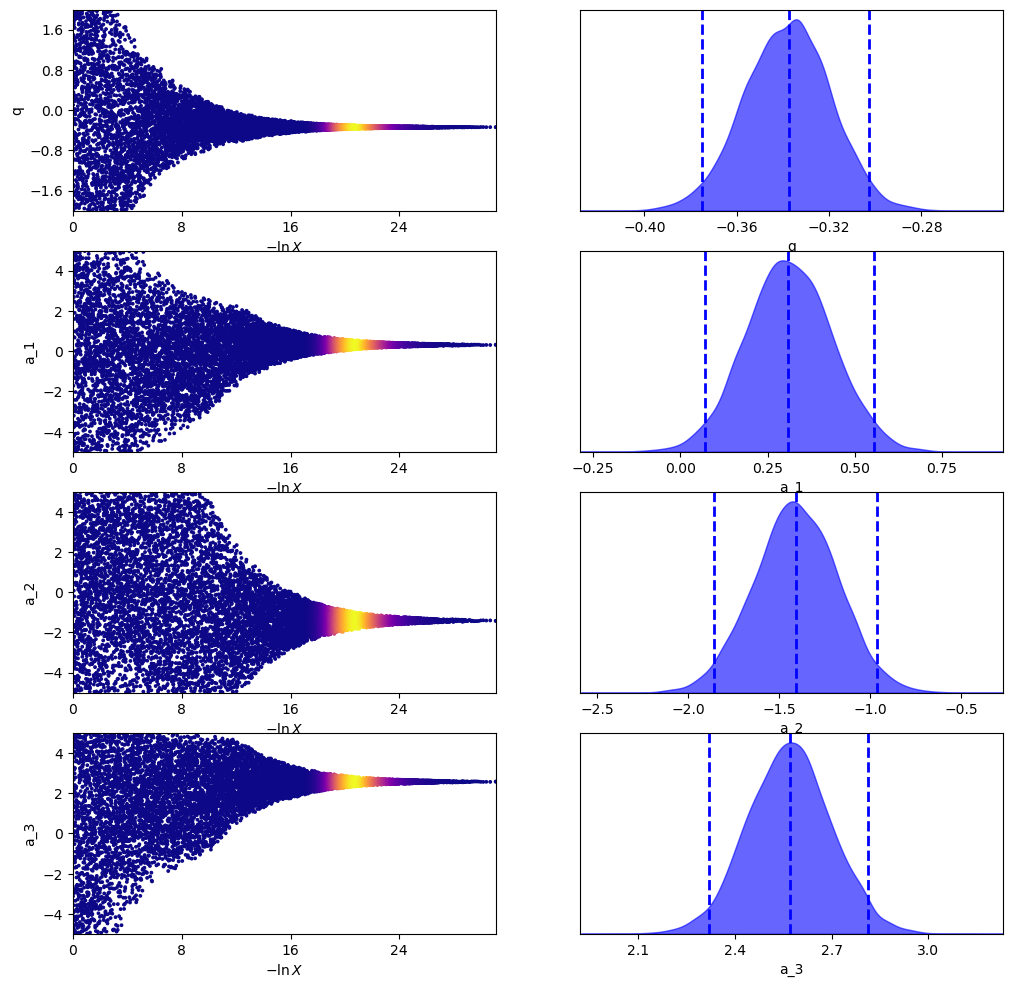

In [11]:
sampler_poly = ultranest.ReactiveNestedSampler(
    parameters_poly, log_poly_likelihood, poly_prior
)
result_poly = sampler_poly.run()
sampler_poly.print_results()
sampler_poly.plot()


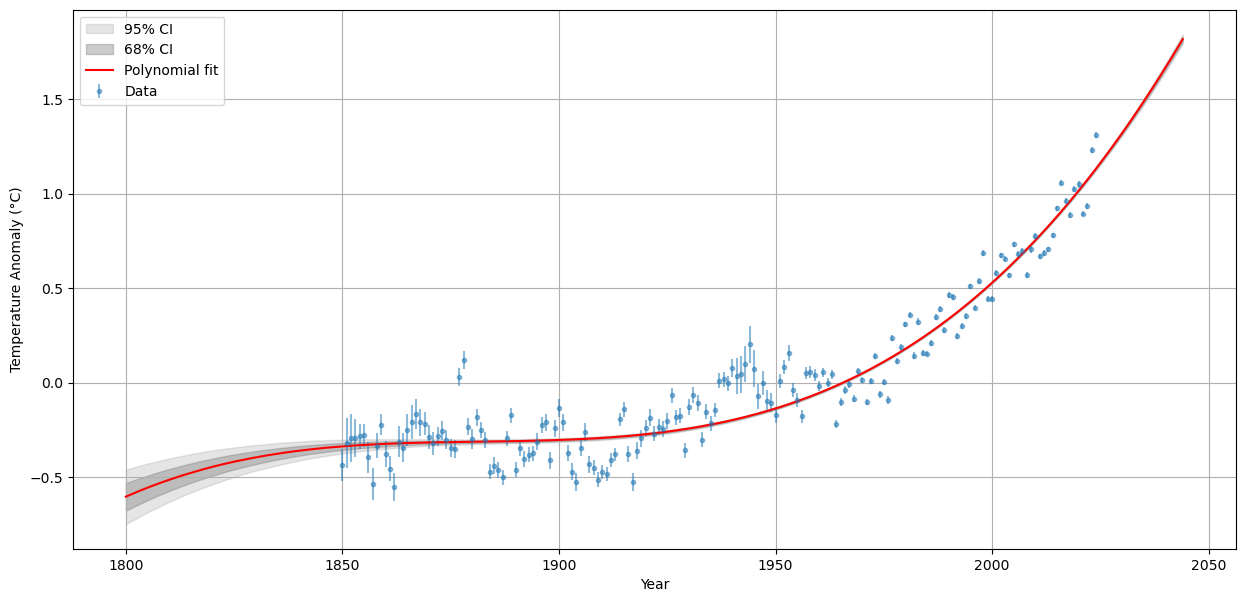

In [12]:
plt.figure(figsize=(15, 7))
plt.errorbar(
    df["year"],
    df["annual_anomaly_above"],
    yerr=yerr_above.to_numpy(),
    fmt="o",
    markersize=3,
    label="Data",
    alpha=0.5,
)

year_range = np.linspace(df["year"].min() - 50, df["year"].max() + 20, 500)
t_range = (year_range - date.min()) / (date.max() - date.min())

# Posterior predictions from the polynomial model
predictions = np.array([
    poly_model(t_range, q, a_1, a_2, a_3)
    for q, a_1, a_2, a_3 in result_poly["samples"]
])

mean_pred = np.median(predictions, axis=0)
lower_68 = np.percentile(predictions, 16, axis=0)
upper_68 = np.percentile(predictions, 84, axis=0)
lower_95 = np.percentile(predictions, 2.5, axis=0)
upper_95 = np.percentile(predictions, 97.5, axis=0)

plt.fill_between(year_range, lower_95, upper_95, color="gray", alpha=0.2, label="95% CI")
plt.fill_between(year_range, lower_68, upper_68, color="gray", alpha=0.4, label="68% CI")
plt.plot(year_range, mean_pred, color="red", linewidth=1.5, label="Polynomial fit")

plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid(True)
plt.legend()
plt.show()

In [6]:
def model_exposc(t, mu, alpha, beta, a1, phi1, T1, a2, phi2, T2):
    trend = mu + alpha * np.exp(beta * t)
    osc1 = a1 * np.sin(2*np.pi*t/T1 + phi1)
    osc2 = a2 * np.sin(2*np.pi*t/T2 + phi2)
    return trend + osc1 + osc2

def exposc_prior(cube):
    theta = cube.copy()

    theta[0] = cube[0] * 4.0 - 2.0      # mu in [-2.0, 2.0]
    theta[1] = cube[1] * 5.5 - 0.5      # alpha in [-0.5, 5.0]
    theta[2] = cube[2] * 5.0            # beta in [0.0, 5.0]
    theta[3] = cube[3] * 0.5 + 0.0      # a1 in [0.0, 0.5]
    theta[4] = cube[4] * 2*np.pi        # phi1 in [0, 2*pi]
    theta[5] = cube[5] * 0.10           # T1 in [0.00, 0.10]
    theta[6] = cube[6] * 0.5 + 0.0      # a2 in [0.0, 0.5]
    theta[7] = cube[7] * 2*np.pi        # phi2 in [0, 2*pi]
    theta[8] = cube[8] * 0.20 + 0.10    # T2 in [0.10, 0.50]

    return theta

inv_sigma2 = 1.0 / sigma2

def log_exposc_likelihood(theta):
    mu, alpha, beta, a1, phi1, T1, a2, phi2, T2 = theta
    model = model_exposc(date_normalized, mu, alpha, beta, a1, phi1, T1, a2, phi2, T2)

    residuals = temp_anomaly - model
    log_likelihood_value = -0.5 * np.sum(
        np.log(2 * np.pi * sigma2) + (residuals ** 2) * inv_sigma2
    )

    return log_likelihood_value

parameters_exposc = ["mu", "alpha", "beta", "a1", "phi1", "T1", "a2", "phi2", "T2"]

[ultranest] Sampling 80 live points from prior ...


[ultranest] Explored until L=-9e+02  .83 [-881.3328..-881.3206] | it/evals=4341/1412700 eff=0.3073% N=80                
[ultranest] Likelihood function evaluations: 1412733
[ultranest]   logZ = -932.7 +- 0.5145
[ultranest] Effective samples strategy satisfied (ESS = 543.2, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.15 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 134 minimum live points (dlogz from 0.42 to 1.27, need <0.5)
[ultranest]   logZ error budget: single: 0.78 bs:0.51 tail:0.10 total:0.52 required:<0.50
[ultranest] Widening roots to 134 live points (have 80 already) ...
[ultranest] Sampling 54 live points from prior ...
[ultranest] Explored until L=-9e+02  .58 [-881.3520..-881.3517]*| it/evals=7312/2353898 eff=0.3162% N=134            4 4 4 
[ultranest] Likelihood function evaluations: 2353898
[ultranest]   logZ = -933.1 +- 0.5314
[ultranest] Effective samples strategy satisfied (ESS = 927.7, need >400)
[ultranest] Po

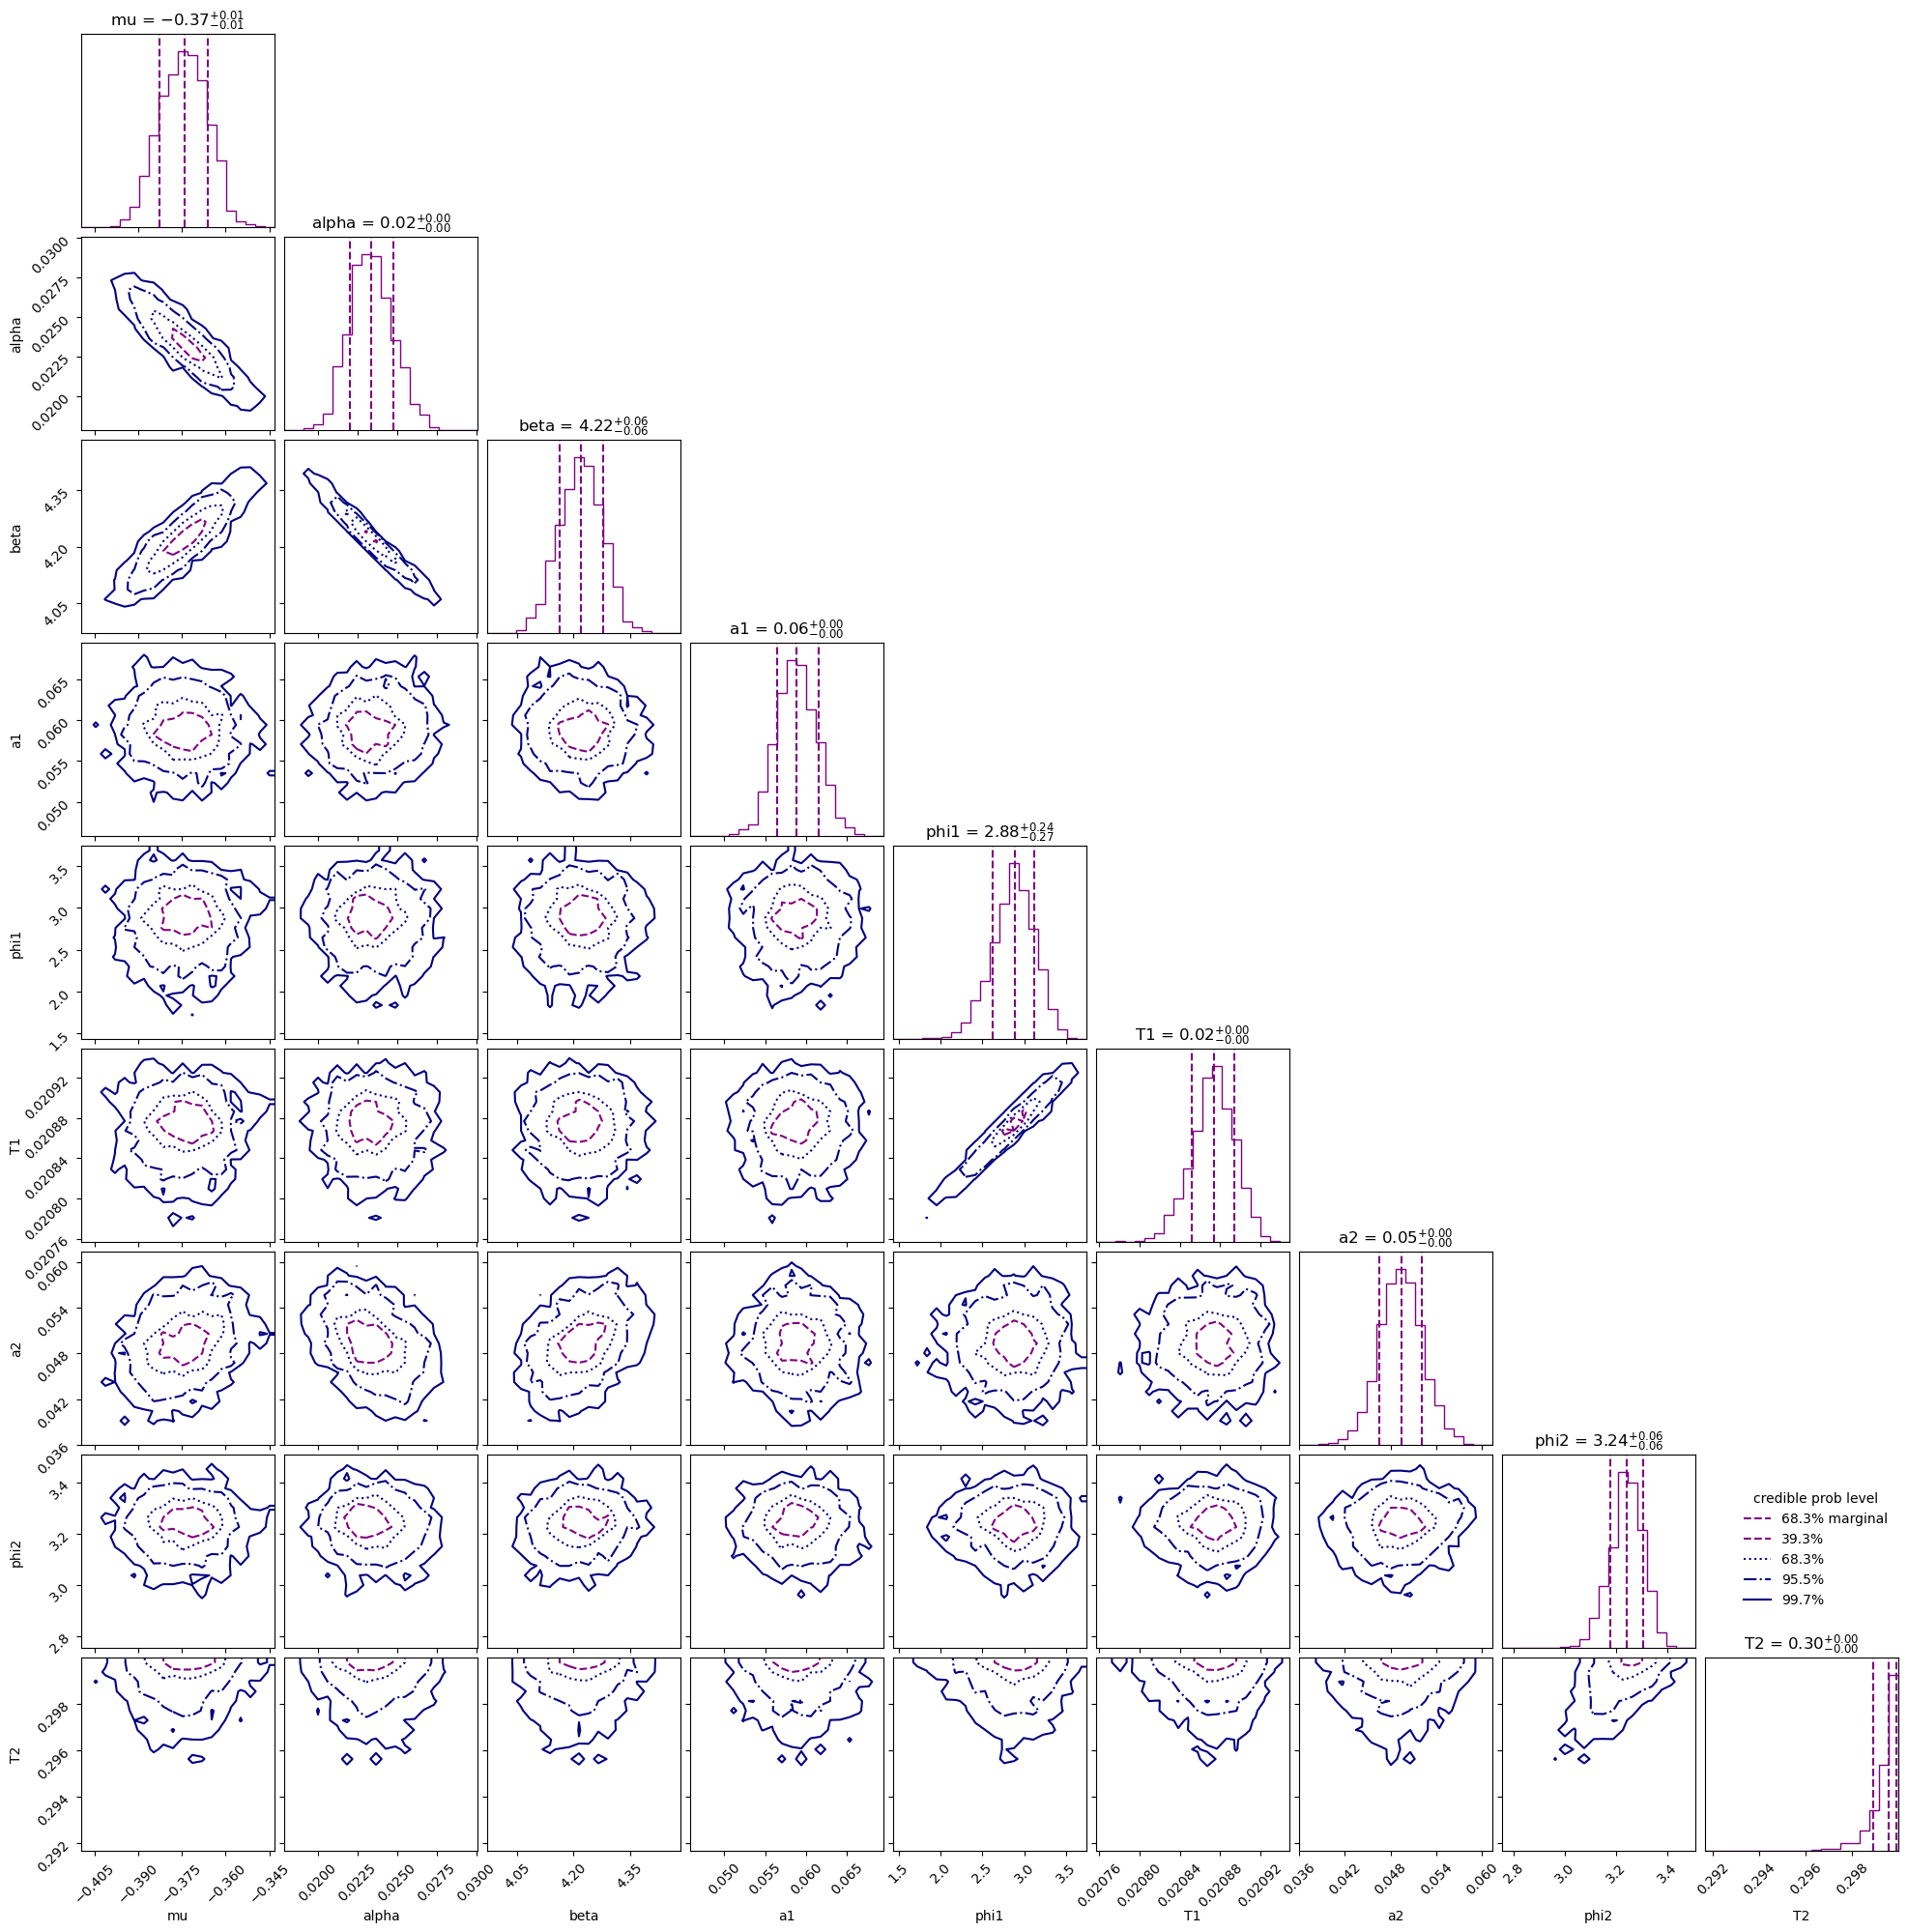

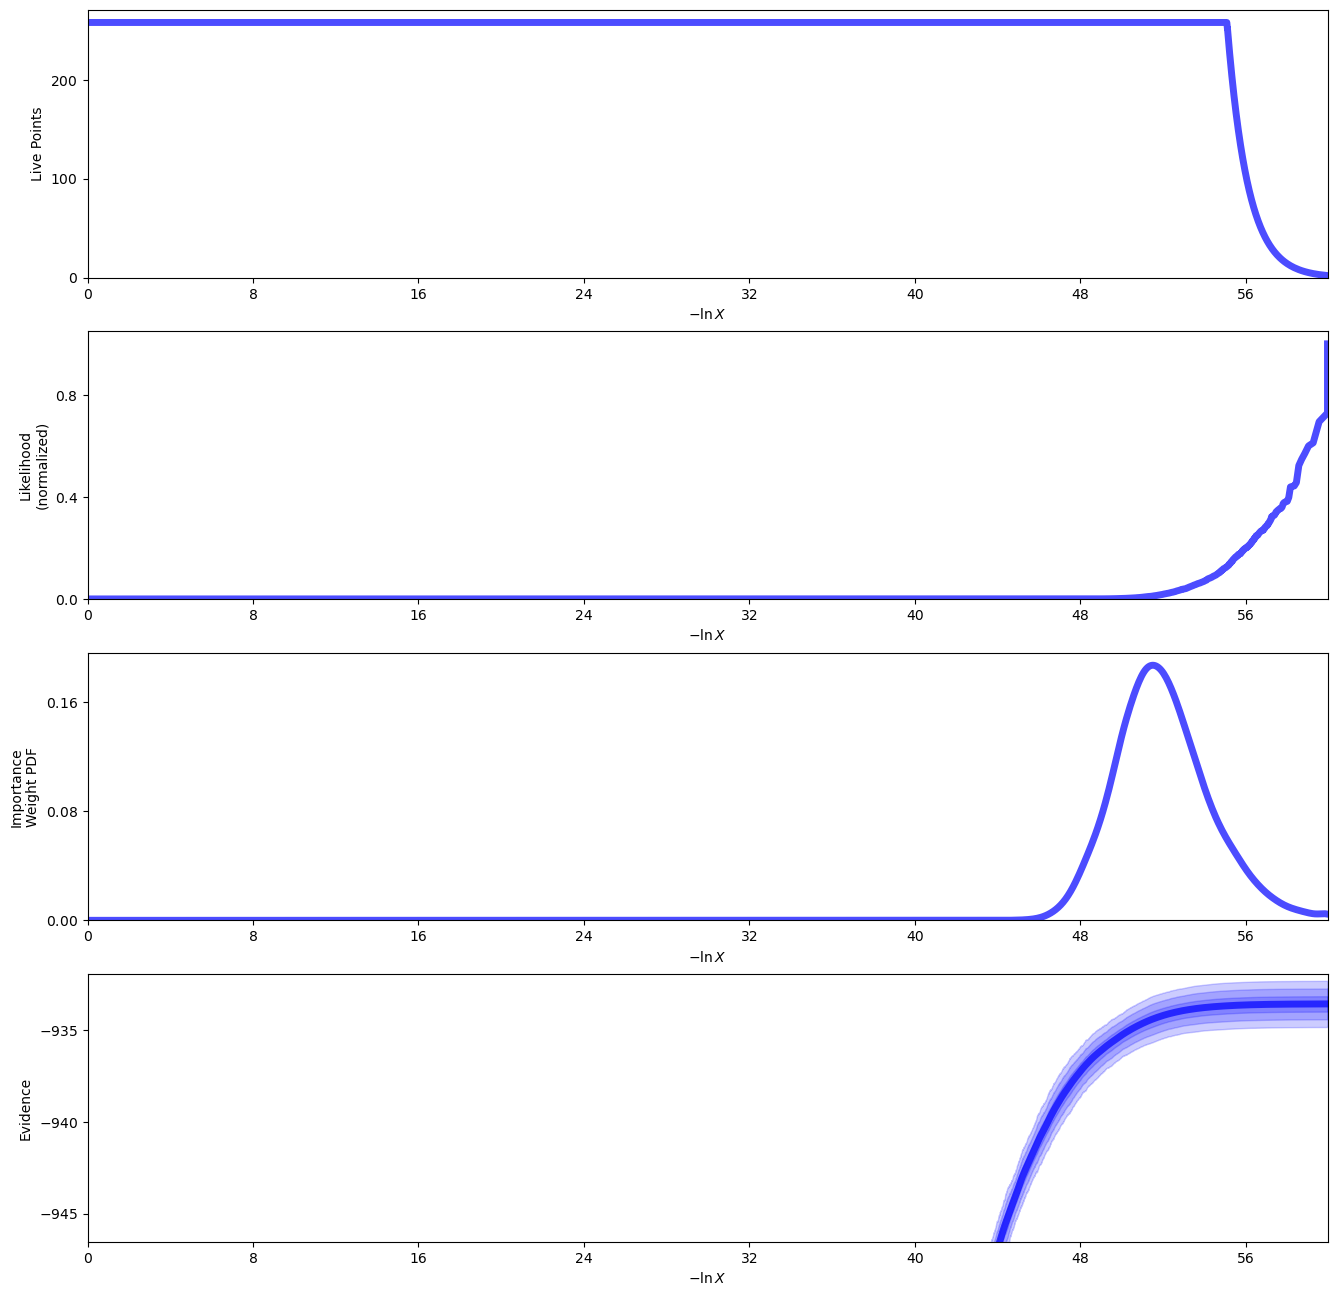

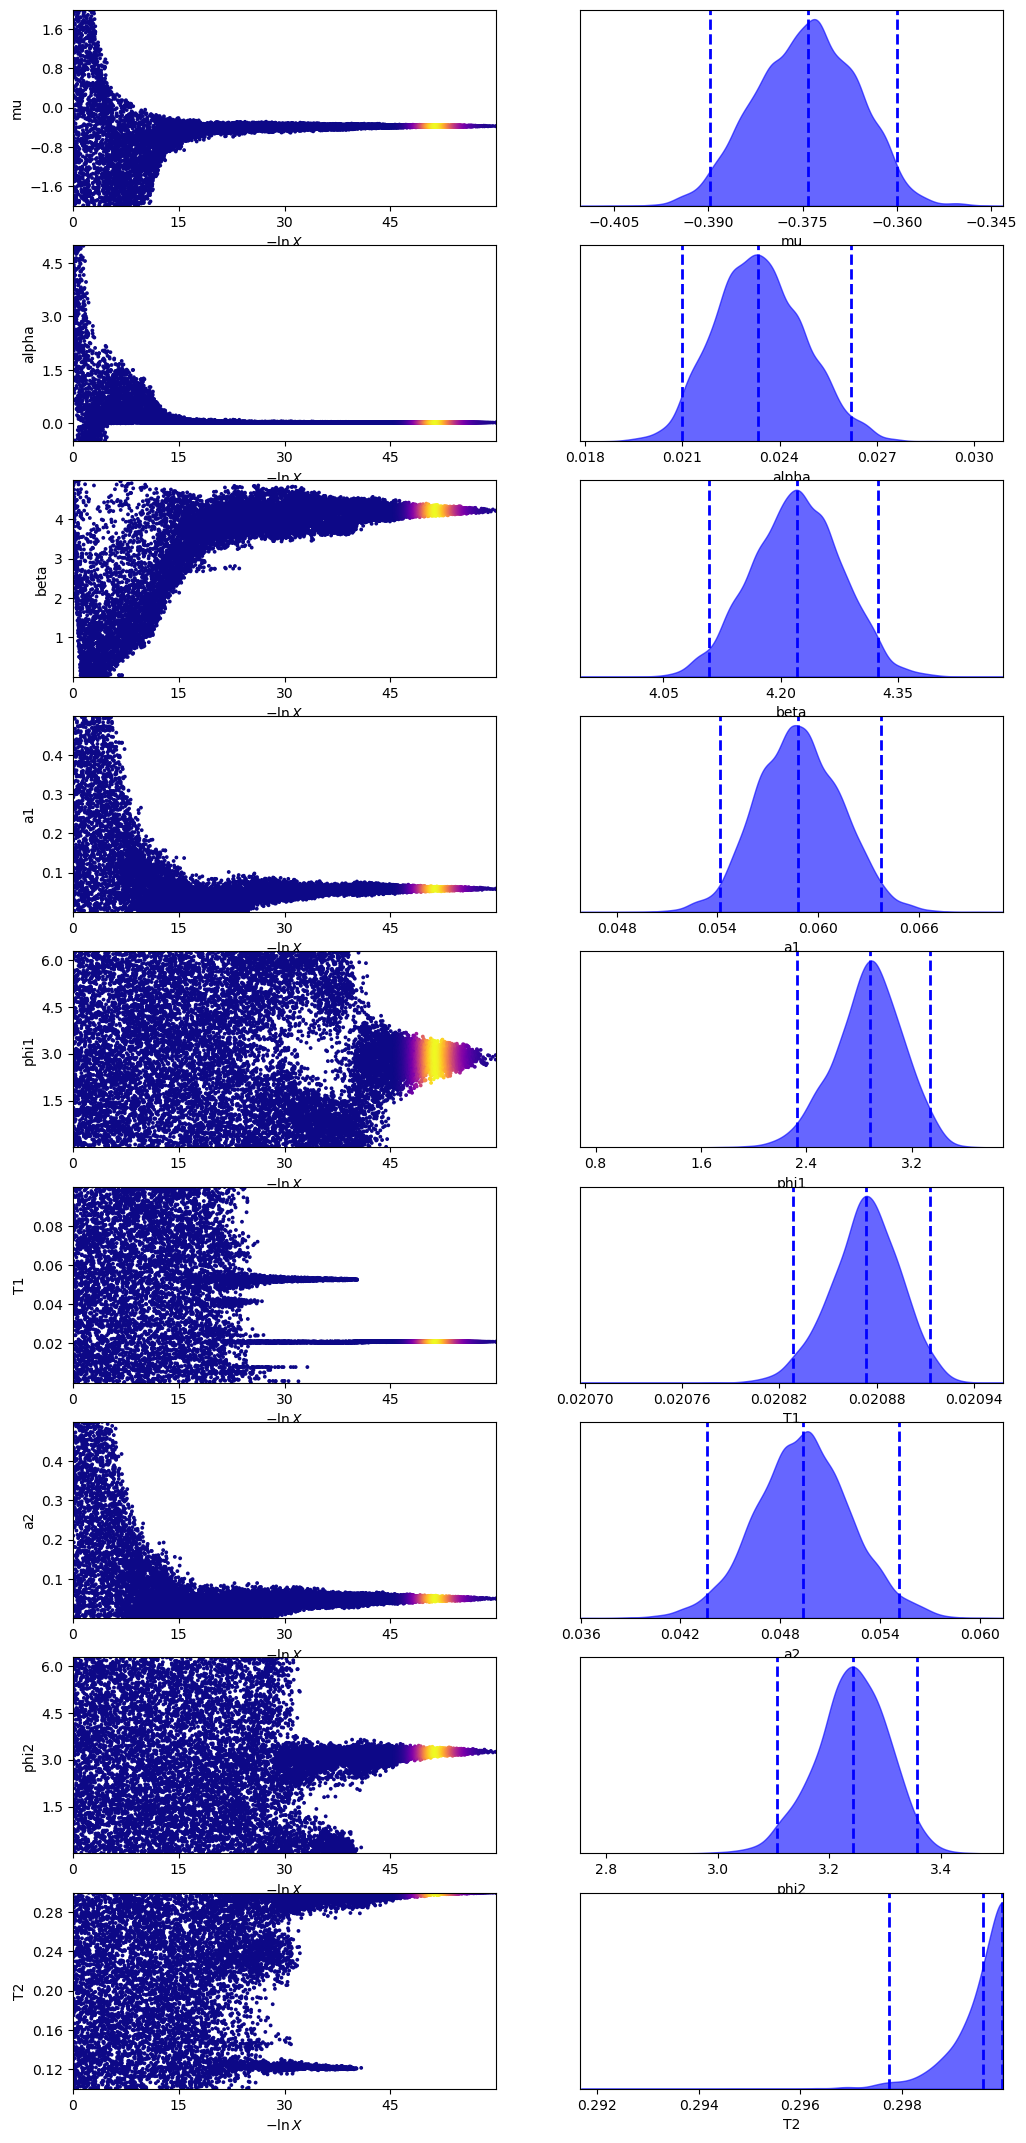

In [7]:
sampler_exposc = ultranest.ReactiveNestedSampler(
    parameters_exposc,
    log_exposc_likelihood,
    exposc_prior
)

sampler_exposc.stepsampler = SliceSampler(
    nsteps=10,
    adaptive_nsteps='move-distance',
    generate_direction=generate_mixture_random_direction,
    max_nsteps=80
)
result_exposc = sampler_exposc.run(
    min_num_live_points=80,
    #min_ess=100,
    frac_remain=0.1,
)
sampler_exposc.print_results()
sampler_exposc.plot()

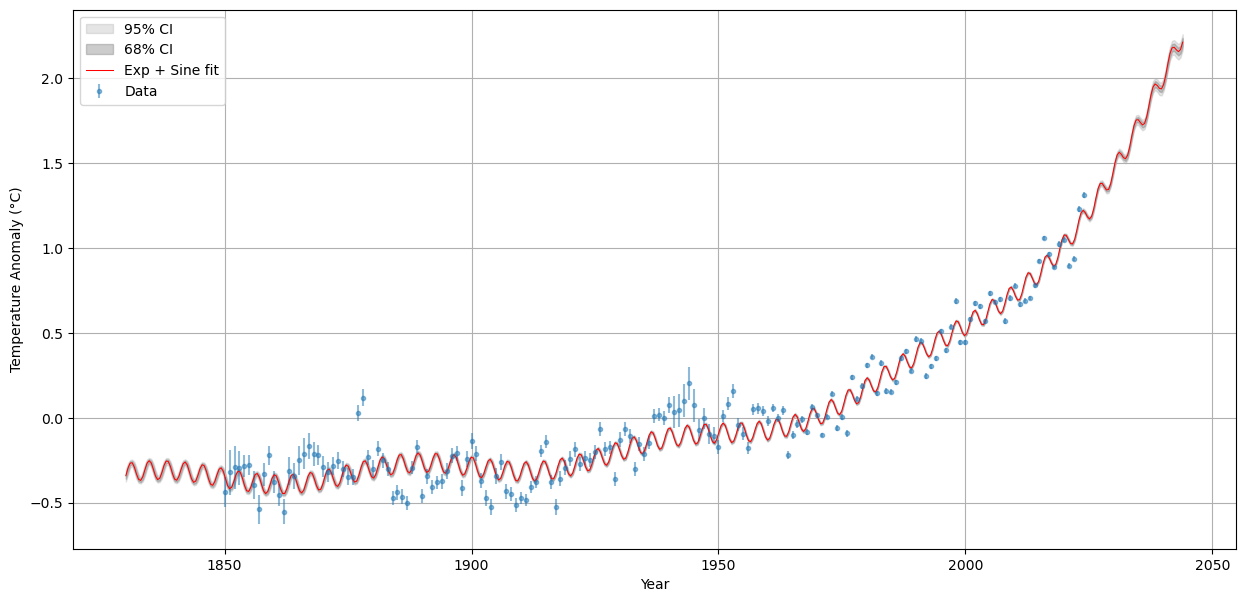

In [9]:
plt.figure(figsize=(15, 7))
plt.errorbar(
    df["year"],
    df["annual_anomaly_above"],
    yerr=yerr_above.to_numpy(),
    fmt="o",
    markersize=3,
    label="Data",
    alpha=0.5,
)

year_range = np.linspace(df["year"].min() - 20, df["year"].max() + 20, 500)
t_range = (year_range - date.min()) / (date.max() - date.min())

# Posterior predictions from the Exp + Sine model
predictions = np.array([
    model_exposc(t_range, mu, alpha, beta, a1, phi1, T1, a2, phi2, T2)
    for mu, alpha, beta, a1, phi1, T1, a2, phi2, T2 in result_exposc["samples"]
])

mean_pred = np.median(predictions, axis=0)
lower_68 = np.percentile(predictions, 16, axis=0)
upper_68 = np.percentile(predictions, 84, axis=0)
lower_95 = np.percentile(predictions, 2.5, axis=0)
upper_95 = np.percentile(predictions, 97.5, axis=0)

plt.fill_between(year_range, lower_95, upper_95, color="gray", alpha=0.2, label="95% CI")
plt.fill_between(year_range, lower_68, upper_68, color="gray", alpha=0.4, label="68% CI")
plt.plot(year_range, mean_pred, color="red", linewidth=0.75, label="Exp + Sine fit")

plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid(True)
plt.legend()
plt.show()

In [13]:
out_dir = Path("results")
out_dir.mkdir(exist_ok=True)

to_save = {
    "result_poly": result_poly,
    "result_exposc": result_exposc,
}

with open(out_dir / "results_trends.pkl", "wb") as f:
    pickle.dump(to_save, f)